# Tugas 1: Gamma Correction

In [1]:
# Persiapan Awal
from google.colab import drive
drive.mount('/content/drive')
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import glob
import os # Import os module for file operations

# Muat gambar
img_gamma_path = '/content/drive/MyDrive/PCVK/female.jpg'
img_gamma = cv2.imread(img_gamma_path)

# Minta input gamma dari pengguna
print('Gamma Correction pada citra')
print('-------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, bukan angka')
    gamma = 1.0 # Default to 1.0 if input is invalid

# Buat Lookup Table (LUT) untuk efisiensi
invGamma = 1.0 / gamma
table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

# Terapkan Gamma Correction menggunakan LUT
gamma_corrected = cv2.LUT(img_gamma, table)

# Gabungkan gambar asli dan hasil untuk ditampilkan
combined_gamma_img = cv2.hconcat([img_gamma, gamma_corrected])

# Simpan gambar gabungan dengan kompresi JPEG
output_gamma_path = '/tmp/gamma_output.jpg'
# Kualitas JPEG antara 0-100. Nilai yang lebih rendah berarti kompresi lebih tinggi.
# Coba nilai 70-90 untuk keseimbangan ukuran dan kualitas.
cv2.imwrite(output_gamma_path, combined_gamma_img, [int(cv2.IMWRITE_JPEG_QUALITY), 85])

# Tampilkan gambar yang sudah dikompres dari file
print("Menampilkan gambar Gamma Correction (dikompres)...")
cv2_imshow(cv2.imread(output_gamma_path))

# Hapus file sementara setelah ditampilkan (opsional)
# os.remove(output_gamma_path)

Output hidden; open in https://colab.research.google.com to view.

# Tugas 2: Simulasi Image Depth

Simulasi Image Depth pada citra Grayscale
--------------------------------------------
Masukkan kedalaman bit (contoh: 1, 2, 4, 8): 2
Menampilkan gambar Simulasi Image Depth (dikompres)...


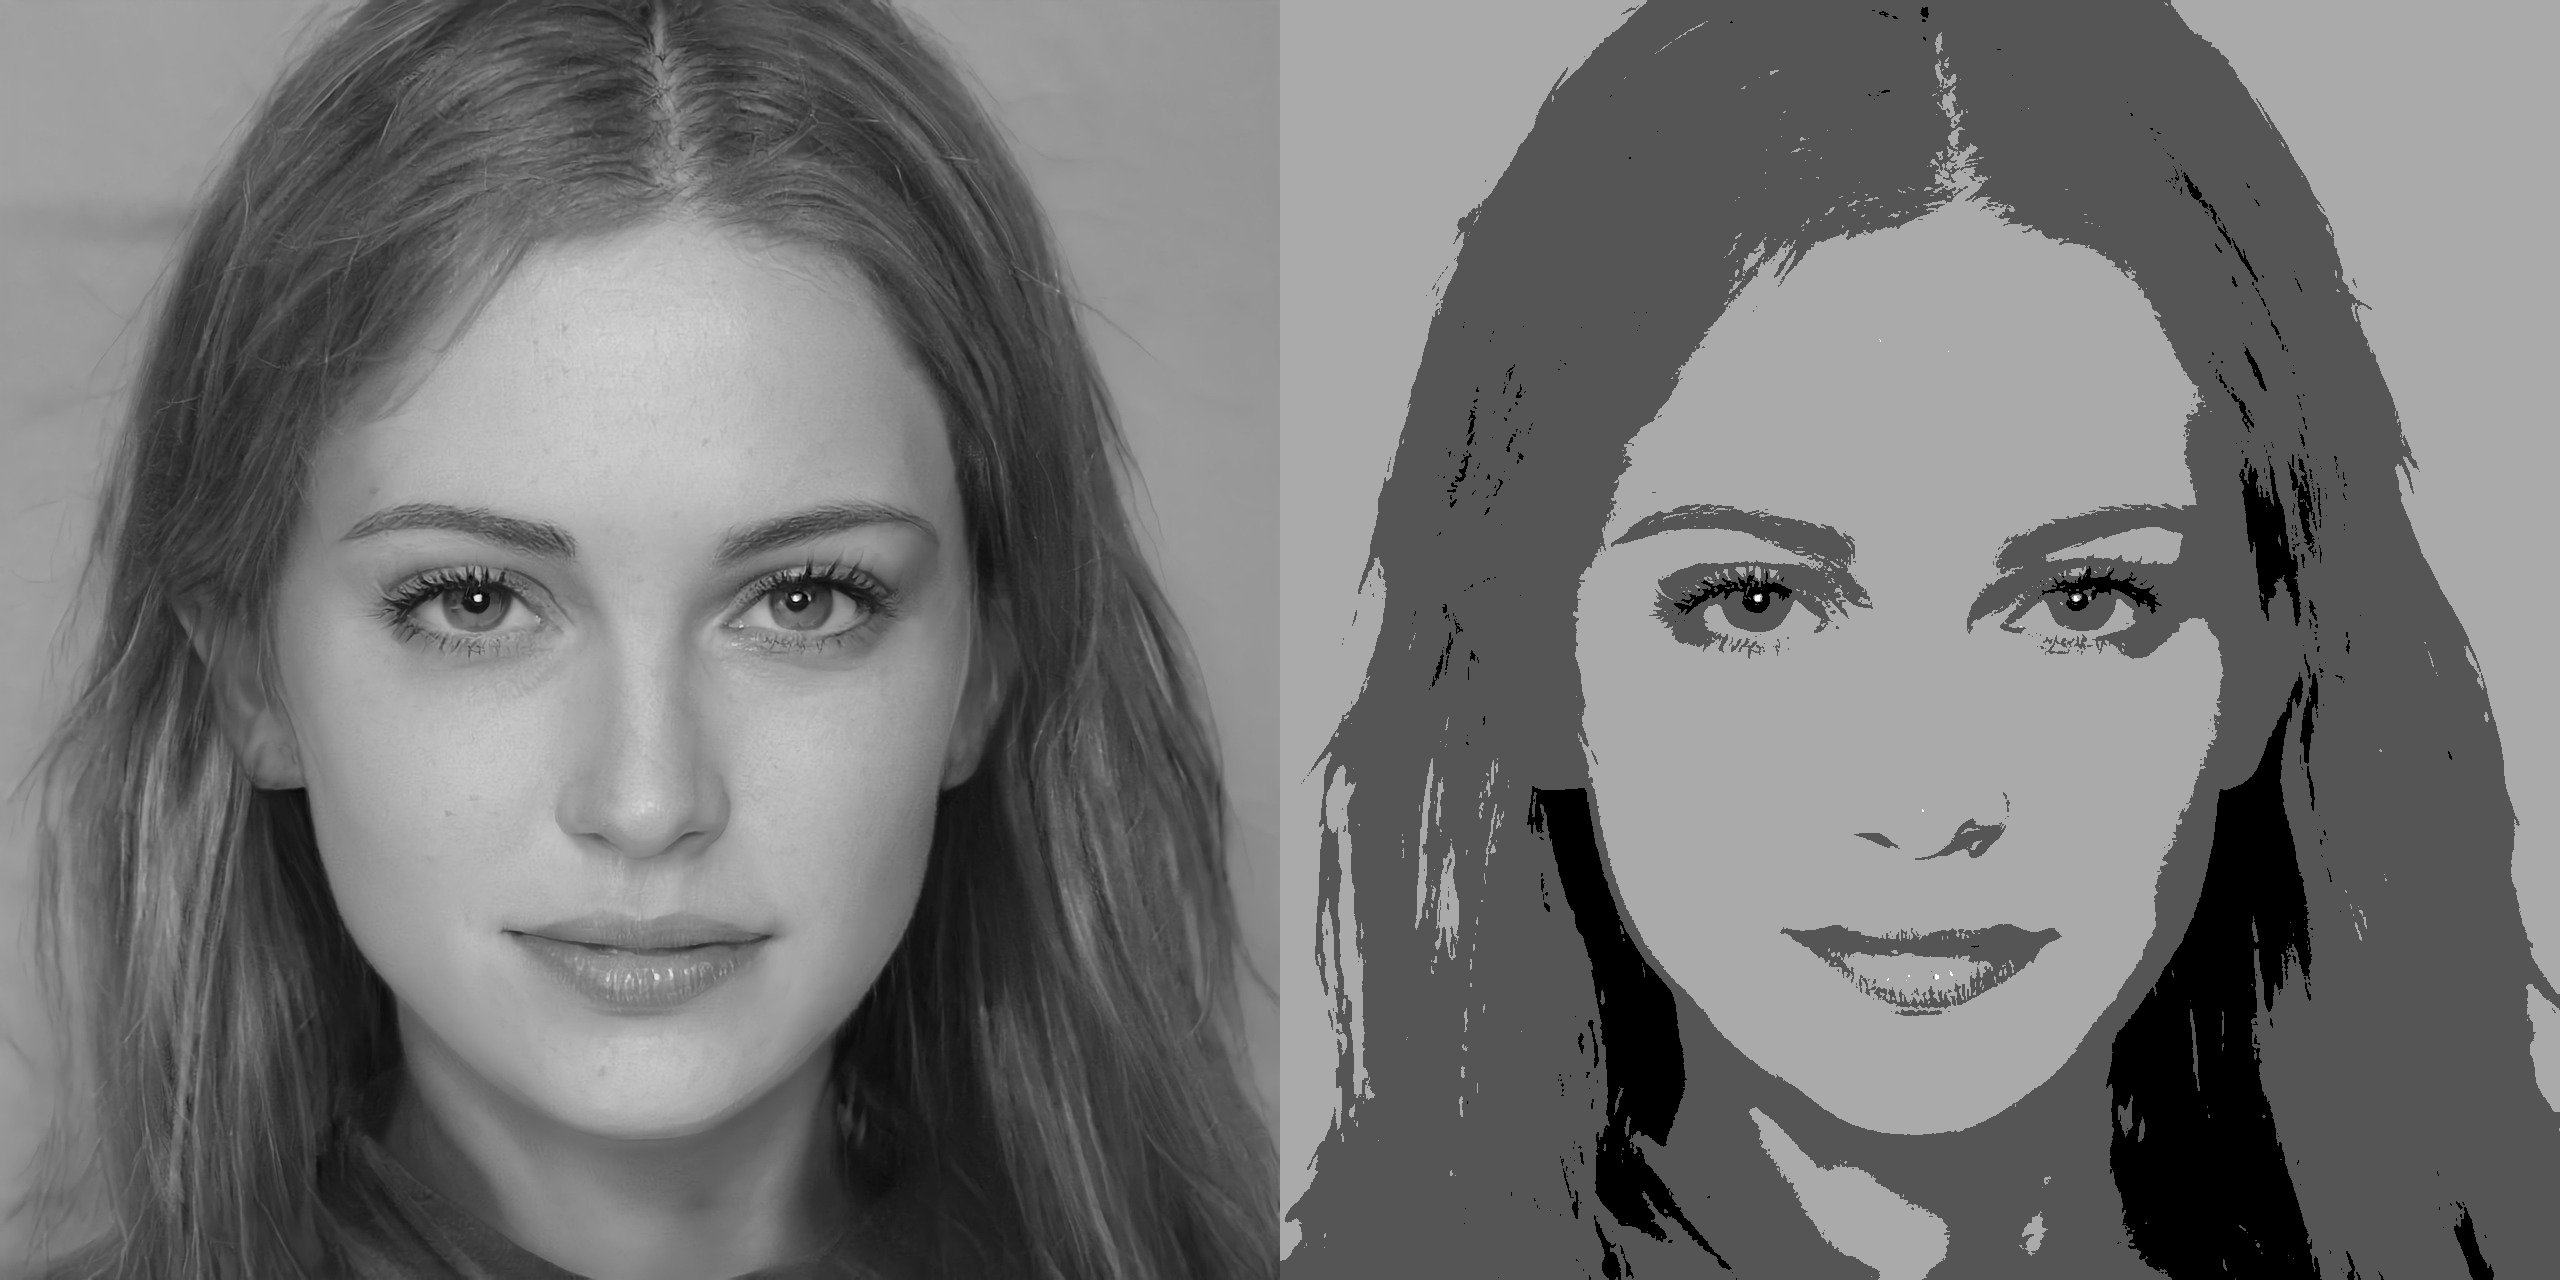

In [2]:
# Muat gambar grayscale
img_depth_path = '/content/drive/MyDrive/PCVK/female.jpg'
original = cv2.imread(img_depth_path, cv2.IMREAD_GRAYSCALE)

# Atur kedalaman bit yang diinginkan (contoh: 2-bit)
print('Simulasi Image Depth pada citra Grayscale')
print('--------------------------------------------')
try:
    bit_depth = int(input('Masukkan kedalaman bit (contoh: 1, 2, 4, 8): '))
    if not 1 <= bit_depth <= 8:
         print('Error: Kedalaman bit harus antara 1 dan 8.')
         bit_depth = 8 # Default to 8 if out of range
except ValueError:
    print('Error: Masukkan angka untuk kedalaman bit.')
    bit_depth = 8 # Default to 8 if invalid input


# Hitung level kuantisasi
level = 255 / (pow(2, bit_depth) - 1)

# Terapkan kuantisasi
depth_image = np.round(original / level) * level
depth_image = depth_image.astype(np.uint8)

# Gabungkan gambar asli dan hasil untuk ditampilkan
combined_depth_img = cv2.hconcat([original, depth_image])

# Simpan gambar gabungan dengan kompresi JPEG
output_depth_path = '/tmp/depth_output.jpg'
# Kualitas JPEG antara 0-100. Nilai yang lebih rendah berarti kompresi lebih tinggi.
cv2.imwrite(output_depth_path, combined_depth_img, [int(cv2.IMWRITE_JPEG_QUALITY), 85])

# Tampilkan gambar yang sudah dikompres dari file
print("Menampilkan gambar Simulasi Image Depth (dikompres)...")
cv2_imshow(cv2.imread(output_depth_path))

# Hapus file sementara setelah ditampilkan (opsional)
# os.remove(output_depth_path)

# Tugas 3: Average Denoising

In [3]:
# 1. Persiapan Awal
# Mengimpor library yang dibutuhkan
import cv2
import numpy as np
import math
from google.colab.patches import cv2_imshow
from google.colab import drive
import os # Import os module for file operations
import matplotlib.pyplot as plt # Import matplotlib for saving figures

# Menghubungkan ke Google Drive
drive.mount('/content/drive')

# Fungsi untuk menghitung PSNR sesuai modul
def PSNR(original, compressed):
    mse = np.mean((original - compressed) ** 2)
    if(mse == 0):  # MSE is zero means no noise is present in the signal .
                  # Therefore PSNR have no importance.
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# 2. Memuat Gambar Asli
# Pastikan path ini sesuai dengan lokasi file Anda
original_galaxy = cv2.imread('/content/drive/MyDrive/PCVK/galaxy.jpg')

# 3. MEMBUAT 100 CITRA BERNOISE (BAGIAN MODIFIKASI)
print("Membuat 100 citra dengan Gaussian noise...")
noisy_images = []
mean = 0
# Sigma (standar deviasi) mengontrol intensitas noise. Coba ubah nilainya (misal: 25, 50).
sigma = 50

for i in range(100): # Use i to potentially save example noisy images
    # Buat salinan gambar asli untuk ditambahkan noise
    image_copy = original_galaxy.copy()

    # Buat noise Gaussian
    gaussian_noise = np.random.normal(mean, sigma, image_copy.shape).astype('uint8')

    # Tambahkan noise ke gambar
    noisy_image = cv2.add(image_copy, gaussian_noise)

    # Simpan gambar bernoise ke dalam list
    noisy_images.append(noisy_image)

print("Pembuatan citra bernoise selesai.")
# Menampilkan contoh gambar bernoise
print("Contoh salah satu gambar yang diberi noise:")
example_noisy_path = '/tmp/example_noisy.jpg'
cv2.imwrite(example_noisy_path, noisy_images[0], [int(cv2.IMWRITE_JPEG_QUALITY), 85])
cv2_imshow(cv2.imread(example_noisy_path))
# os.remove(example_noisy_path)


# 4. Proses Denoising dan Kalkulasi PSNR
# Bagian ini sama seperti pada modul, tetapi menggunakan list gambar yang baru kita buat
avg_counts = [5, 10, 20, 40, 80, 100]
psnr_results_table = []

print("\n--- Memulai Proses Average Denoising ---")
for count in avg_counts:
    # Ambil sejumlah gambar bernoise dari list
    # Konversi ke float untuk perhitungan rata-rata yang akurat
    selected_images = np.array(noisy_images[:count], dtype=float)

    # Hitung rata-ratanya
    avg_image = np.mean(selected_images, axis=0).astype(np.uint8)

    # Hitung PSNR antara gambar hasil denoising dengan gambar asli
    psnr_val = PSNR(original_galaxy, avg_image)

    # Simpan hasilnya untuk tabel
    psnr_results_table.append((count, f"{psnr_val:.2f} dB"))

    # Tampilkan gambar hasil denoising
    print(f"Hasil Rata-rata dari {count} Citra:")
    output_denoised_path = f'/tmp/denoised_{count}.jpg'
    cv2.imwrite(output_denoised_path, avg_image, [int(cv2.IMWRITE_JPEG_QUALITY), 85])
    cv2_imshow(cv2.imread(output_denoised_path))
    # os.remove(output_denoised_path)


# 5. Menampilkan Tabel dan Kesimpulan
print("\n--- Tabel Hasil PSNR ---")
print("Jumlah Citra\t | Nilai PSNR (dB)")
print("-----------------------------------")
for count, psnr_str in psnr_results_table:
    print(f"{count}\t\t | {psnr_str}")

print("\n--- Kesimpulan ---")
print("Berdasarkan hasil yang didapat, dapat disimpulkan bahwa semakin banyak jumlah citra yang dirata-ratakan, maka 'noise' pada citra hasil akan semakin berkurang. Hal ini dibuktikan dengan nilai PSNR yang secara konsisten meningkat seiring bertambahnya jumlah citra. Nilai PSNR yang lebih tinggi menandakan kualitas gambar yang lebih baik dan lebih mendekati citra aslinya.")

Output hidden; open in https://colab.research.google.com to view.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Menampilkan gambar 'Operasi AND (Masking Kepala)' (dikompres)...


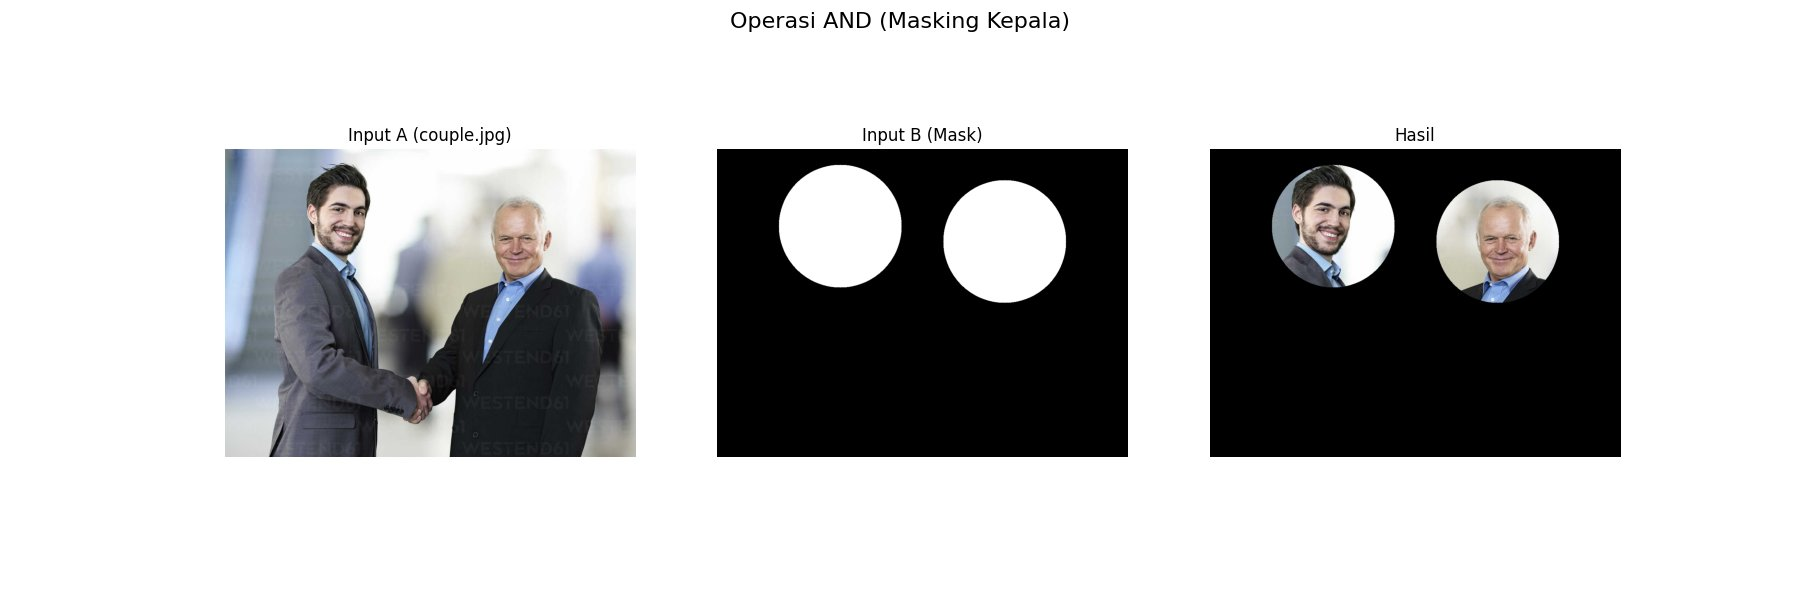

Menampilkan gambar 'Operasi OR' (dikompres)...


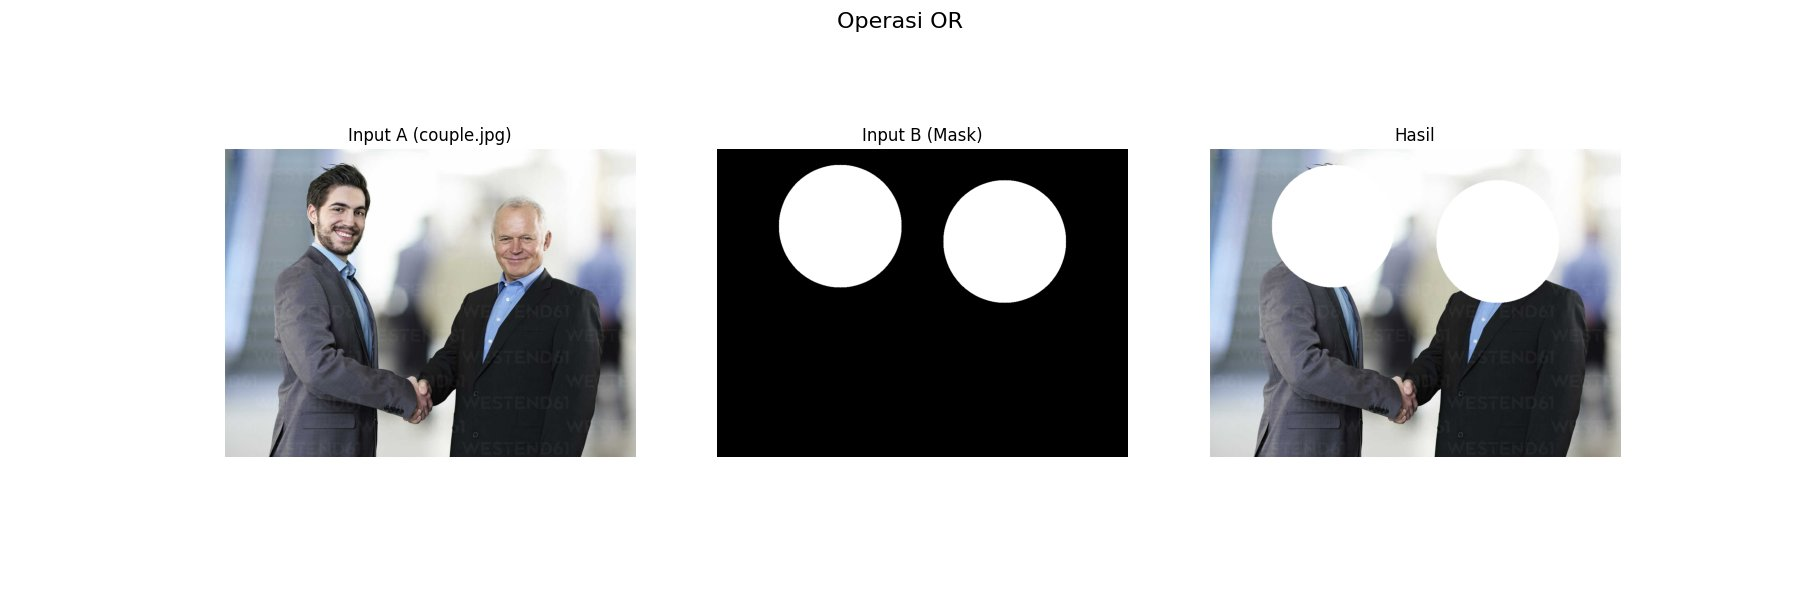

Menampilkan gambar 'Operasi XOR' (dikompres)...


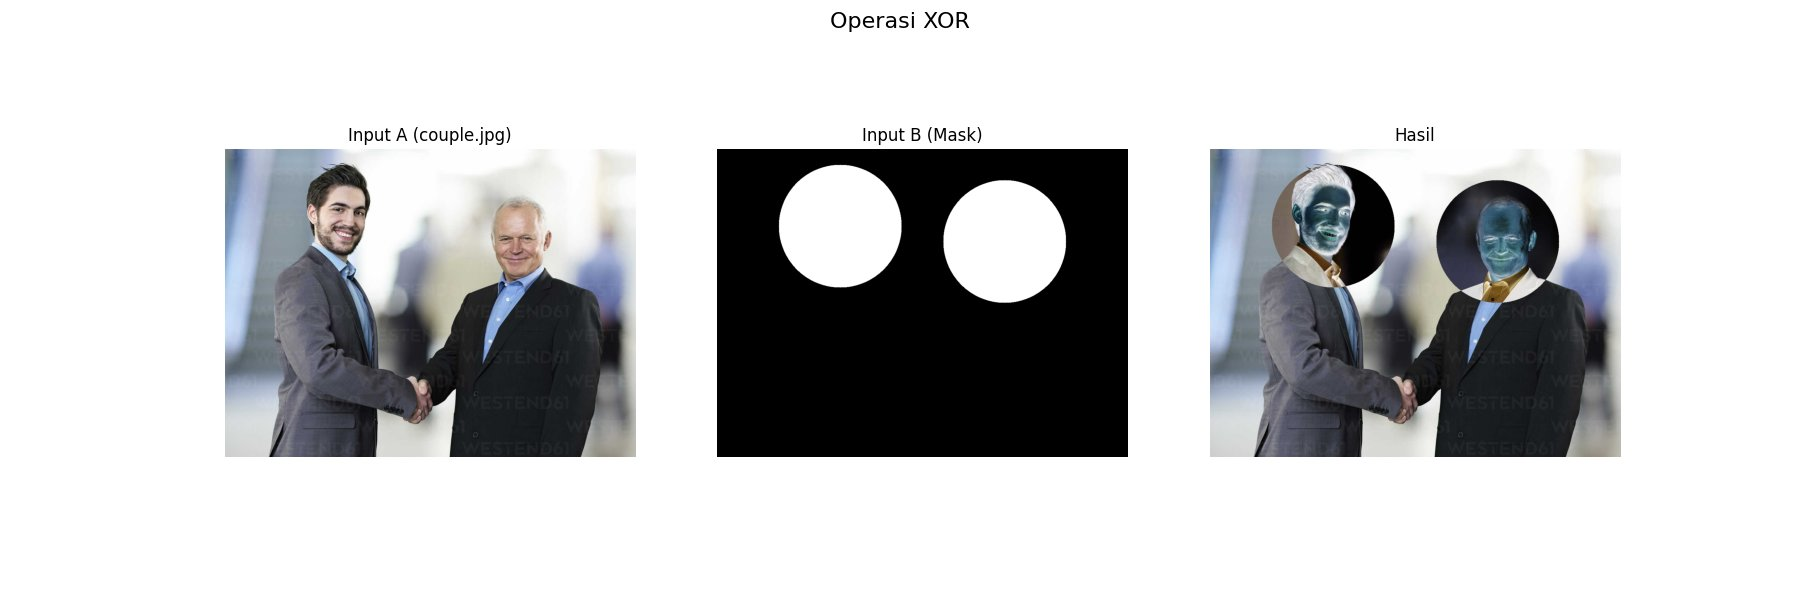

Menampilkan gambar 'Operasi NOT' (dikompres)...


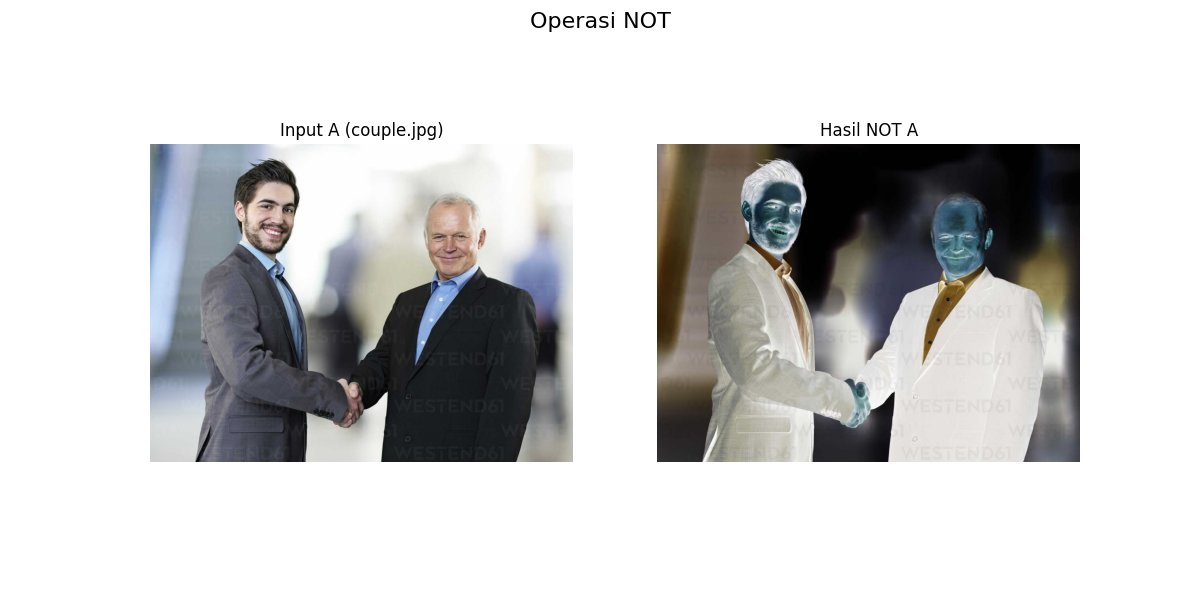

Menampilkan gambar 'Operasi NAND (NOT AND)' (dikompres)...


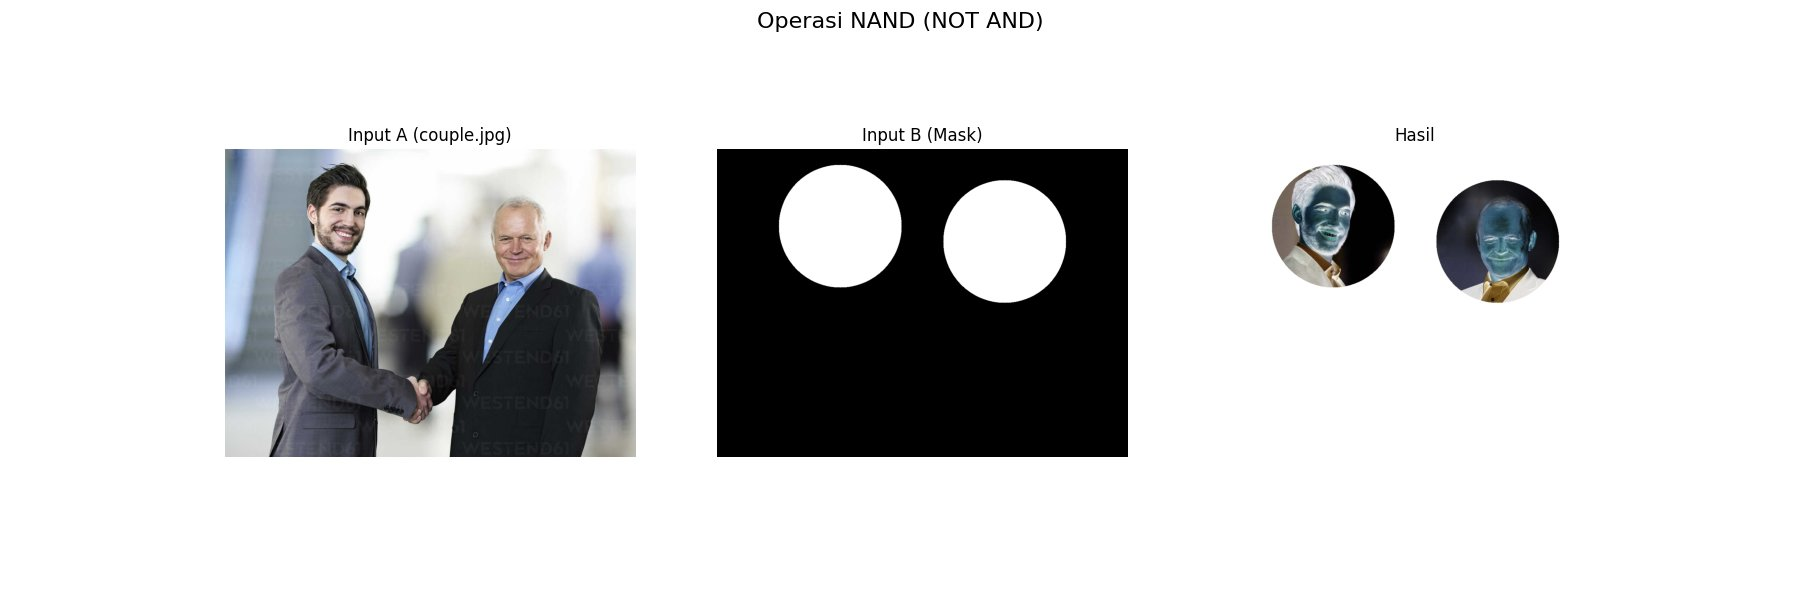

In [5]:
# 1. Persiapan Awal
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os # Import os module for file operations

# Pastikan Google Drive sudah terhubung
drive.mount('/content/drive')

# 2. Memuat Gambar Input A (couple.jpg)
# Pastikan path ini sesuai dengan lokasi file Anda di Google Drive
path_couple = '/content/drive/MyDrive/PCVK/couple.jpg'
img_A = cv2.imread(path_couple)

# Pastikan gambar berhasil dimuat
if img_A is None:
    print(f"Error: Tidak dapat menemukan gambar di path: {path_couple}")
else:
    # 3. Membuat Gambar Input B (Mask Dua Lingkaran di Kepala)
    # Membuat gambar hitam dengan ukuran yang sama seperti img_A
    mask_B = np.zeros_like(img_A)
    h, w, _ = img_A.shape

    # --- KOORDINAT LINGKARAN UNTUK KEPALA ---
    # Ini adalah perkiraan koordinat berdasarkan gambar yang Anda berikan.
    # Anda mungkin perlu menyesuaikan nilai-nilai ini sedikit jika tidak pas.

    # Kepala orang kiri (pria muda)
    center_head1 = (int(w * 0.3), int(h * 0.25)) # x, y
    radius_head1 = int(min(h, w) * 0.2)        # Radius lingkaran

    # Kepala orang kanan (pria tua)
    center_head2 = (int(w * 0.7), int(h * 0.3)) # x, y
    radius_head2 = int(min(h, w) * 0.2)        # Radius lingkaran

    # Menggambar dua lingkaran putih pada mask
    cv2.circle(mask_B, center_head1, radius_head1, (255, 255, 255), thickness=-1)
    cv2.circle(mask_B, center_head2, radius_head2, (255, 255, 255), thickness=-1)

    # Fungsi untuk menampilkan perbandingan visual dengan kompresi
    def show_comparison_images_compressed(title, input_a, input_b, result, filename_prefix, input_a_title='Input A (couple.jpg)', input_b_title='Input B (Mask)'):
        plt.figure(figsize=(18, 6))
        plt.suptitle(title, fontsize=16)

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(input_a, cv2.COLOR_BGR2RGB))
        plt.title(input_a_title)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(cv2.cvtColor(input_b, cv2.COLOR_BGR2RGB))
        plt.title(input_b_title)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        plt.title('Hasil')
        plt.axis('off')

        # Simpan gambar figure tanpa kompresi kualitas di matplotlib
        temp_output_path = f'/tmp/{filename_prefix}_temp.png' # Use PNG to avoid initial loss
        output_path = f'/tmp/{filename_prefix}_comparison.jpg'
        plt.savefig(temp_output_path, format='png')
        plt.close() # Close the figure to free memory

        # Muat kembali gambar dan simpan dengan kompresi JPEG menggunakan cv2
        temp_img = cv2.imread(temp_output_path)
        if temp_img is not None:
             # Kualitas JPEG antara 0-100. Nilai yang lebih rendah berarti kompresi lebih tinggi.
            cv2.imwrite(output_path, temp_img, [int(cv2.IMWRITE_JPEG_QUALITY), 85])
            # Tampilkan gambar yang sudah dikompres dari file
            print(f"Menampilkan gambar '{title}' (dikompres)...")
            cv2_imshow(cv2.imread(output_path))
            # Hapus file sementara (opsional)
            # os.remove(temp_output_path)
            # os.remove(output_path)
        else:
            print(f"Error: Tidak dapat memuat gambar sementara dari {temp_output_path}")


    # 4. Menerapkan dan Memvisualisasikan Setiap Operator

    # --- Operator AND ---
    # Menampilkan hanya bagian kepala yang ada di dalam lingkaran.
    result_and = cv2.bitwise_and(img_A, mask_B)
    show_comparison_images_compressed('Operasi AND (Masking Kepala)', img_A, mask_B, result_and, 'and_op')

    # --- Operator OR ---
    # Menggabungkan gambar A dengan mask B. Lingkaran putih mask akan menimpa area hitam gambar A.
    result_or = cv2.bitwise_or(img_A, mask_B)
    show_comparison_images_compressed('Operasi OR', img_A, mask_B, result_or, 'or_op')

    # --- Operator XOR ---
    # Area di dalam lingkaran akan menampilkan inversi warna kepala.
    result_xor = cv2.bitwise_xor(img_A, mask_B)
    show_comparison_images_compressed('Operasi XOR', img_A, mask_B, result_xor, 'xor_op')

    # --- Operator NOT ---
    # Membalikkan semua warna pada gambar A.
    result_not_A = cv2.bitwise_not(img_A)
    # Untuk NOT, kita tampilkan input dan hasil saja
    plt.figure(figsize=(12, 6))
    plt.suptitle('Operasi NOT', fontsize=16)
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_A, cv2.COLOR_BGR2RGB))
    plt.title('Input A (couple.jpg)')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(result_not_A, cv2.COLOR_BGR2RGB))
    plt.title('Hasil NOT A')
    plt.axis('off')

    # Simpan gambar figure NOT tanpa kompresi kualitas di matplotlib
    temp_output_not_path = '/tmp/not_op_temp.png'
    output_not_path = '/tmp/not_op_comparison.jpg'
    plt.savefig(temp_output_not_path, format='png')
    plt.close() # Close the figure

    # Muat kembali gambar dan simpan dengan kompresi JPEG menggunakan cv2
    temp_not_img = cv2.imread(temp_output_not_path)
    if temp_not_img is not None:
        cv2.imwrite(output_not_path, temp_not_img, [int(cv2.IMWRITE_JPEG_QUALITY), 85])
        # Tampilkan gambar NOT yang sudah dikompres
        print("Menampilkan gambar 'Operasi NOT' (dikompres)...")
        cv2_imshow(cv2.imread(output_not_path))
        # os.remove(temp_output_not_path)
        # os.remove(output_not_path)
    else:
        print(f"Error: Tidak dapat memuat gambar sementara dari {temp_output_not_path}")


    # --- Operator NAND (NOT AND) ---
    # Area kepala di dalam lingkaran akan menjadi hitam, sisa gambar terbalik warnanya.
    result_nand = cv2.bitwise_not(result_and) # Menggunakan hasil dari operasi AND
    show_comparison_images_compressed('Operasi NAND (NOT AND)', img_A, mask_B, result_nand, 'nand_op')

Analisa Hasil Visual

Dengan menjalankan kode di atas, Anda akan mendapatkan 5 set gambar perbandingan:

- AND: Hasilnya akan menampilkan area irisan antara lingkaran dan persegi, yaitu bentuk setengah lingkaran di sisi kanan.

- OR: Hasilnya akan menampilkan gabungan dari kedua bentuk, yaitu sebuah lingkaran penuh dengan tambahan area persegi di sisi kanannya.

- XOR: Hasilnya akan menampilkan area di mana kedua bentuk tidak tumpang tindih. Anda akan melihat setengah lingkaran di kiri dan area persegi di kanan yang tidak tertutup oleh lingkaran.

- NOT: Hasilnya adalah kebalikan dari Input A, yaitu sebuah gambar hitam dengan lubang berbentuk lingkaran di tengahnya.

- NAND: Hasilnya adalah kebalikan dari AND. Anda akan melihat sebuah gambar putih dengan lubang berbentuk setengah lingkaran di area irisan tadi.